In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from iminuit import Minuit, cost

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

## #6_1 Bayes 


In [3]:
def likelihood_fct(k,n,p):
    y=stats.binom.pmf(k,n,p)
    return y

def prior_fct(p):
    y=beta_distribution(p,5,17)
    return y


def beta_distribution(x,alpha, beta):
    y=stats.beta.pdf(x,alpha,beta)
    return y


def posterior_fct(k,n,p):
    y=likelihood_fct(k,n,p)*prior_fct(p)
    return y

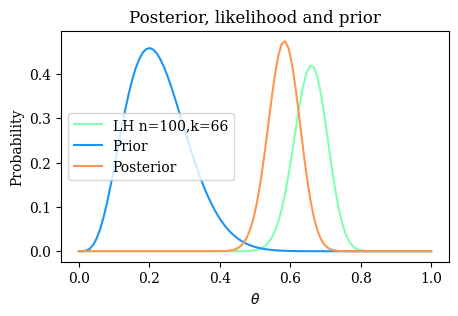

In [4]:
"""plot the likelihood function"""

n=100
k=66

theta_min=0
theta_max=1

theta_array=np.linspace(theta_min,theta_max,100)
lh_array=[]
prior_array=[]
posterior_array=[]

for theta in theta_array:
    lh=likelihood_fct(k,n,theta)
    lh_array.append(lh*5)

    prior=prior_fct(theta)
    prior_array.append(prior/10)

    post=posterior_fct(k,n,theta)
    posterior_array.append(post*2000)
    #print(f'{theta:.2f} {prob:.2e}')

fig,ax=plt.subplots()
ax.plot(theta_array,lh_array,color=my_cmap(0.5),label=f"LH n={n},k={k}")
ax.plot(theta_array,prior_array,color=my_cmap(0.2),label=f"Prior")
ax.plot(theta_array,posterior_array,color=my_cmap(0.8),label=f"Posterior")
#ax.set_ylim(0,1)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'Probability')
ax.set_title('Posterior, likelihood and prior')
ax.legend()
plt.show()

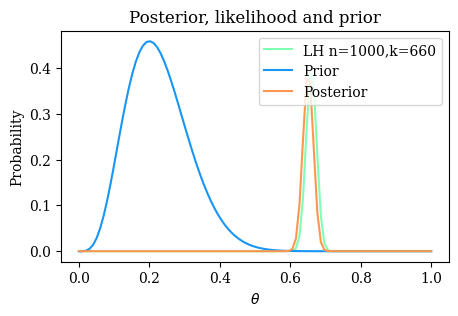

In [11]:
"""plot the likelihood function"""

n=1000
k=660

theta_min=0
theta_max=1

theta_array=np.linspace(theta_min,theta_max,100)
lh_array=[]
prior_array=[]
posterior_array=[]

for theta in theta_array:
    lh=likelihood_fct(k,n,theta)
    lh_array.append(lh*15)

    prior=prior_fct(theta)
    prior_array.append(prior/10)

    post=posterior_fct(k,n,theta)
    posterior_array.append(post*20000)
    #print(f'{theta:.2f} {prob:.2e}')

fig,ax=plt.subplots()
ax.plot(theta_array,lh_array,color=my_cmap(0.5),label=f"LH n={n},k={k}")
ax.plot(theta_array,prior_array,color=my_cmap(0.2),label=f"Prior")
ax.plot(theta_array,posterior_array,color=my_cmap(0.8),label=f"Posterior")
#ax.set_ylim(0,1)
ax.set_xlabel(r'$\theta$')
ax.set_ylabel(r'Probability')
ax.set_title('Posterior, likelihood and prior')
ax.legend()
plt.show()

## #2 Markov Chain


In [5]:
"""creating the markov chain and sampling data"""


def pdf(x,x_t,sigma=1):
    y=1/(sigma*np.sqrt(2*np.pi)) * np.exp(-0.5*(x-0.5*x_t)**2/sigma**2)
    return y


def markov_step(x):
    x=r.normal(loc=0.5*x,scale=1)#or accept reject from pdf
    return x


def markov_chain_run(t_array,starting_point=100):
    x_array=[]
    x=starting_point
    for i in t_array:
        x=markov_step(x)
        x_array.append(x)
    return x_array

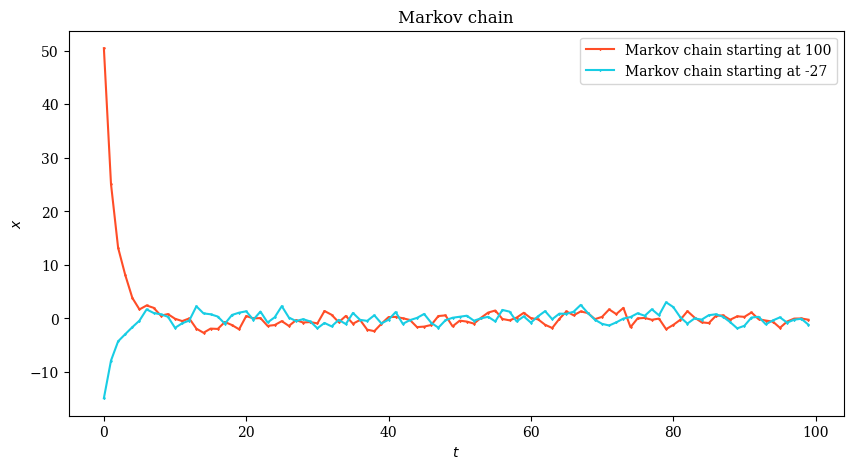

In [6]:
"""generating data"""
n_steps=100


t_array=np.arange(n_steps)
x_array1=markov_chain_run(starting_point=100,t_array=t_array)

x_array2=markov_chain_run(starting_point=-27,t_array=t_array)


"""plotting the markov chain"""
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(t_array,x_array1,color=my_cmap(0.9),marker=my_marker,markersize=2,label=f"Markov chain starting at 100")
ax.plot(t_array,x_array2,color=my_cmap(0.3),marker=my_marker,markersize=2,label=f"Markov chain starting at -27")
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$x$')
ax.set_title('Markov chain')
ax.legend()
plt.show()
